In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

In [3]:
# Leer CSV 
df = pd.read_csv(
    "zahn.csv",
    sep="\t",
    header=None,
    names=["X", "Y", "referencia"]
)

print(df.head())
print(f"\nNúmero de puntos: {len(df)}")

X = df[["X", "Y"]] # Tomamos x,y

# Estandarizar X, Y con z-score
scaler = StandardScaler()
X_s = scaler.fit_transform(X)

# Hiperparámetros
epsilons = [0.20, 0.30, 0.40]
min_samples = 5

resultados = []
labels_por_epsilon = {}


       X      Y  referencia
0  26.75  22.15           0
1  29.80  22.15           0
2  31.55  21.10           0
3  27.70  20.85           0
4  29.90  19.95           0

Número de puntos: 399


In [4]:
# Ejecutar DBSCAN para cada epsilon
for eps in epsilons:

    db = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = db.fit_predict(X_s)

    # Guardamos las etiquetas para usarlas después
    labels_por_epsilon[eps] = labels

    # Número de clusters
    # No contamos -1 porque representa ruido
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Número de puntos de ruido
    n_ruido = np.sum(labels == -1)

    # Número de core points
    n_core = len(db.core_sample_indices_)

    # Border points
    n_border = len(df) - n_core - n_ruido

    resultados.append({
        "epsilon": eps,
        "clusters": n_clusters,
        "ruido": n_ruido,
        "core": n_core,
        "border": n_border
    })


In [5]:
# Resultados
tabla_resultados = pd.DataFrame(resultados)

print("\nResultados DBSCAN:")
print(tabla_resultados.to_string(index=False))


Resultados DBSCAN:
 epsilon  clusters  ruido  core  border
     0.2         5     76   306      17
     0.3         3     36   345      18
     0.4         3      6   375      18


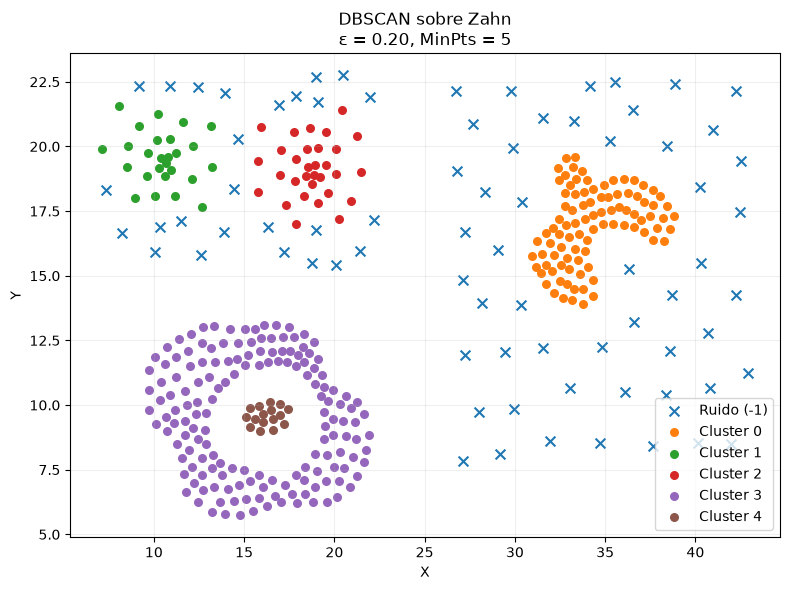

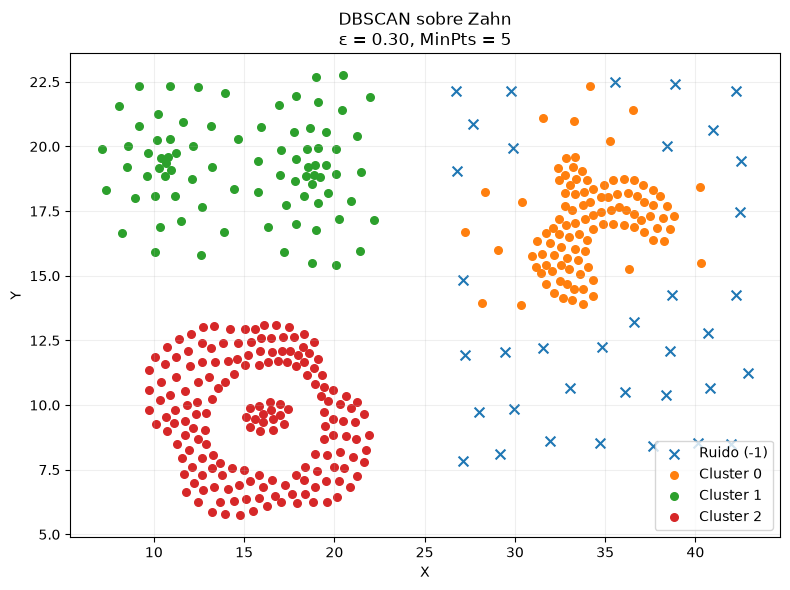

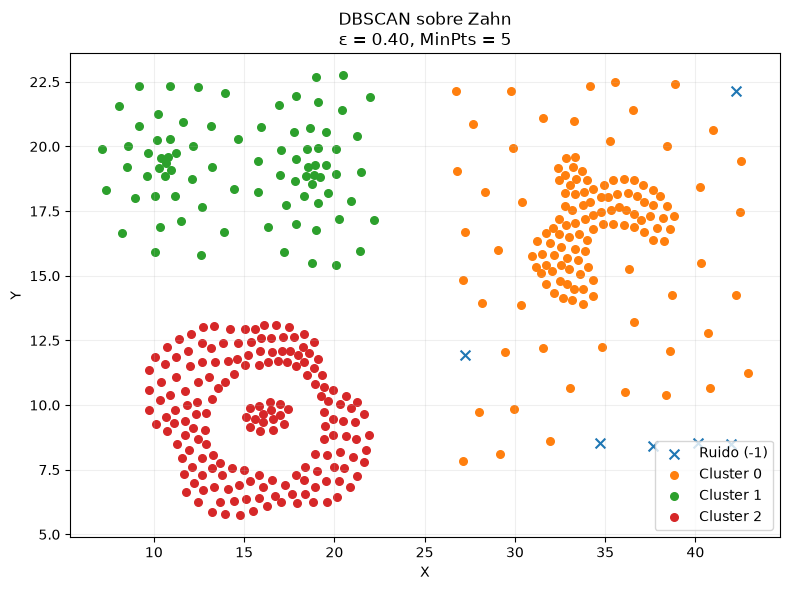

In [6]:
# Graficar resultados
for eps in epsilons:

    labels = labels_por_epsilon[eps]

    plt.figure(figsize=(8, 6))

    # Dibujar cada cluster
    clusters = sorted(set(labels))

    for cluster in clusters:

        mascara = labels == cluster

        if cluster == -1:
            # Ruido
            plt.scatter(
                df.loc[mascara, "X"],
                df.loc[mascara, "Y"],
                marker="x",
                s=50,
                label="Ruido (-1)"
            )
        else:
            plt.scatter(
                df.loc[mascara, "X"],
                df.loc[mascara, "Y"],
                s=30,
                label=f"Cluster {cluster}"
            )

    plt.title(
        f"DBSCAN sobre Zahn\n"
        f"ε = {eps:.2f}, MinPts = {min_samples}"
    )

    plt.xlabel("X")
    plt.ylabel("Y")

    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()

    plt.show()

In [7]:
# Guardamos los resultados en resultado_dbscan.csv
resultado_dbscan = pd.DataFrame({
    "indice": df.index
})

for eps in epsilons:

    labels = labels_por_epsilon[eps]

    resultado_dbscan[f"label_eps_{eps:.2f}"] = labels
    resultado_dbscan[f"ruido_eps_{eps:.2f}"] = labels == -1

resultado_dbscan.to_csv(
    "resultado_dbscan.csv",
    index=False
)

resultado_dbscan.head()

,indice,label_eps_0.20,ruido_eps_0.20,label_eps_0.30,ruido_eps_0.30,label_eps_0.40,ruido_eps_0.40
0,0,-1,True,-1,True,0,False
1,1,-1,True,-1,True,0,False
2,2,-1,True,0,False,0,False
3,3,-1,True,-1,True,0,False
4,4,-1,True,-1,True,0,False
